In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from pprint import pprint

from functools import partial

import numpy as np
from sklearn.preprocessing import scale
# import sklearn.metrics as metrics

import matplotlib.pyplot as plt
import matplotlib.animation as ani

import mlgrad.models as models
import mlgrad.regr as regr
import mlgrad.cls as cls
import mlgrad.pca as pca
import mlgrad.plots as plots
import mlgrad.funcs as funcs
import mlgrad.funcs2 as funcs2
import mlgrad.loss as loss
import mlgrad.gd as gd
import mlgrad.smooth as smooth
import mlgrad.inventory as inventory
from mlgrad.af import averaging_function
import mlgrad.avragg as avragg

import rampy
import pybaselines
import random

from irsa import io
from irsa.preprocess import despike, utils
import irsa.widgets as widgets
import irsa.spectra as spectra
import irsa.io as io

import scipy.special as special

import copy

import ipywidgets
from IPython.display import display

import sys
print(sys.version)

# %matplotlib widget

3.13.11 (main, Dec  8 2025, 11:43:54) [GCC 15.2.0]


In [2]:
path = f"/home/intellimath/YD/repos/spectra/13"
options = {}
dd = {}
# widgets.load_spectra(path, dd, options)

In [3]:
# dd = io.load_spectra(path, {"вид_бактерий":"STR", "отсечки_по_молекулярной_массе":"less30more10"})
# dd = io.load_spectra(path, {"штамм_бактерий":["36", "95", "B", "C"], "тип_измерения_спектров":["SE"],
#                             "отсечки_по_молекулярной_массе": ["less100"],})
# dd = io.load_spectra(path, {"штамм_бактерий":["36", "95"], #"A", "B", "C", "D"], 
#                              "отсечки_по_молекулярной_массе": "less100",
#                              "тип_измерения_спектров":"SE"})
# dd = io.load_spectra(path, {})
dd = io.load_spectra(path, {"вид_бактерий":["SA", "SS", "SH"], 
                            "номер_цикла":["13"], 
                            # "номер_эксперимента_в_цикле":["1"],
                            # "отсечки_по_молекулярной_массе": ["more100"],
                            
                           }, verbose=False)

In [4]:
dd.align_bottom()
dd.crop(400)

In [5]:
dd.plot_sigma_mu(1.0, n_component=0.90)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260112_SH_1…

In [6]:
# dd.select_for_exclusion(sigma_mu=0.15)
dd.exclude_by_default(sigma_mu=0.15)

In [7]:
# dd.exclude_selected()

In [8]:
dd.drop_zeros_spectrum()

In [9]:
# dd.plot_spectra(0, n_component=0.99)

In [10]:
dd.isfinite()

In [11]:
# dd.select_baselines(tau2=1.0e6, tau2_smooth=0.0, func=funcs.Step(0.00, eps=0.001), func2=funcs.Step(0.00, 0.001))

In [12]:
dd2 = spectra.SpectraCollection()
for key, sp in dd.spectra.items():
    dd2[key] = sp.robust_averaging(tau=3.5)

In [13]:
dd2.isfinite()

In [14]:
dd2.drop_notfinite()

In [15]:
dd2.drop_zeros_spectrum()

In [16]:
# dd2.plot_spectra(0.0)

In [17]:
# dd2.scale_by_mean(scale=10.0)

In [18]:
# dd2.select_baselines(tau2=1.0e6, func=funcs.Step(0.00, 0.001), 
#                      # func2=funcs.Step(0.00, 0.001),
#                      tau2_smooth=0.0) #, func2_e=inventory.relative_abs_max)

In [19]:
# dd2.isfinite()

In [20]:
# dd2.select_for_exclusion()

In [21]:
# dd2.apply(lambda x, y: np.log(y+1))

In [22]:
# dd2.apply(lambda x, y: y+(y.max()-y.min())/(x.max()-x.min())*(x-x.min()))

In [23]:
# dd2.apply(lambda x, y: np.exp(y)-1)

In [24]:
# dd2.scale_by_max()
# dd2.scale_by_mean()

In [25]:
# dd2.plot_spectra(n_component=0.99)

In [26]:
# dd2.plot_logscale()

In [27]:
# dd2.loglog()

In [28]:
# dd2.logscale()

In [29]:
# dd2.smooth(method="irsa", tau2=1.0)

In [30]:
# dd2.plot_smoothed(tau2=1.0, func=None, xrange=(700,1000))
# dd2.plot_smoothed(tau2=1.0, func=funcs.SoftAbs_Sqrt(1.0).derivative_div_array, xrange=(700,1000))
# dd2.plot_smoothed(tau2=1.0, func=funcs.SoftAbs_Sqrt(0.001).derivative_div_array, 
#                   func2=funcs.SoftAbs_Sqrt(0.001).derivative_div_array, xrange=(700,1100)) #, func2_e=inventory.relative_abs_max)

In [24]:
# dd2.select_baselines(tau2=1.0e6, tau2_smooth=0.0, func=funcs.Step(0.00, eps=0.001), 
#                      # func2=funcs.Step(0.1, eps=0.001), 
#                      d=4)

dd2.select_baselines(tau2=1.0e6, tau2_smooth=0.0, 
                     func=funcs.Step(1.0, eps=0.001), 
                     func2=funcs.Step(0.0, eps=0.001),
                     func2_e=inventory.relative_abs_max,
                     d=2)

# dd2.select_baselines(tau2=1.0e6, func=smooth.func_aspls, func2_e=inventory.relative_abs_max)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260112_SH_1…

In [25]:
def subtract_baseline(x, y, tau2=1.0e6):
    bl, dd = smooth.whittaker_smooth_weight_func2(
        y,
        func=funcs.Step(0.001, eps=0.001),
        func2=funcs.Step(0.001, eps=0.001),
        # func2_e=inventory.relative_abs_max,
        tau2=tau2, d=4)
    y -= bl
    y /= abs(y).mean()
    return y

dd2.apply_par(subtract_baseline, inplace=True)
dd2.plot_spectra(0)

20260112_SH_15__13_2_1_2_super_SE__H2O(HPLC)_
20260112_SH_15__13_2_1_3_super_SE__H2O(HPLC)_
20260112_SH_15__13_2_1_1_super_SE__H2O(HPLC)_
20251222_SS_17__13_1_1_1_super_SE__H2O(HPLC)_
20251222_SS_17__13_1_1_2_super_SE__H2O(HPLC)_
20251222_SS_17__13_1_1_3_super_SE__H2O(HPLC)_
20260115_SH_15__13_5_1_1_super_SE__H2O(HPLC)_
20260119_SH_15__13_5_1_3_super_SE__H2O(HPLC)_
20260119_SH_15__13_5_1_2_super_SE__H2O(HPLC)_
20260114_SH_15__13_4_1_2_super_SE__H2O(HPLC)_
20260114_SH_15__13_4_1_1_super_SE__H2O(HPLC)_
20260114_SH_15__13_4_1_3_super_SE__H2O(HPLC)_
20260114_SS_17__13_4_1_1_super_SE__H2O(HPLC)_
20260114_SS_17__13_4_1_2_super_SE__H2O(HPLC)_
20260114_SS_17__13_4_1_3_super_SE__H2O(HPLC)_
20251222_SA_97__13_1_1_2_super_SE__H2O(HPLC)_
20251222_SA_97__13_1_1_3_super_SE__H2O(HPLC)_
20251222_SA_97__13_1_1_1_super_SE__H2O(HPLC)_
20251222_SH_15__13_1_1_2_super_SE__H2O(HPLC)_
20251222_SH_15__13_1_1_3_super_SE__H2O(HPLC)_
20251222_SH_15__13_1_1_1_super_SE__H2O(HPLC)_
20260112_SS_17__13_2_1_3_super_SE_

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260112_SH_1…

In [35]:
dd3 = dd2

In [ ]:
dd2.plot_topf(tval=0, crop=400, n_peaks=None)

In [ ]:
dd3 = dd2.topf(tval=0, crop=400, sub_valleys=False)

In [34]:
dd2.plot_spectra(tau2_smooth=0)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260112_SH_1…

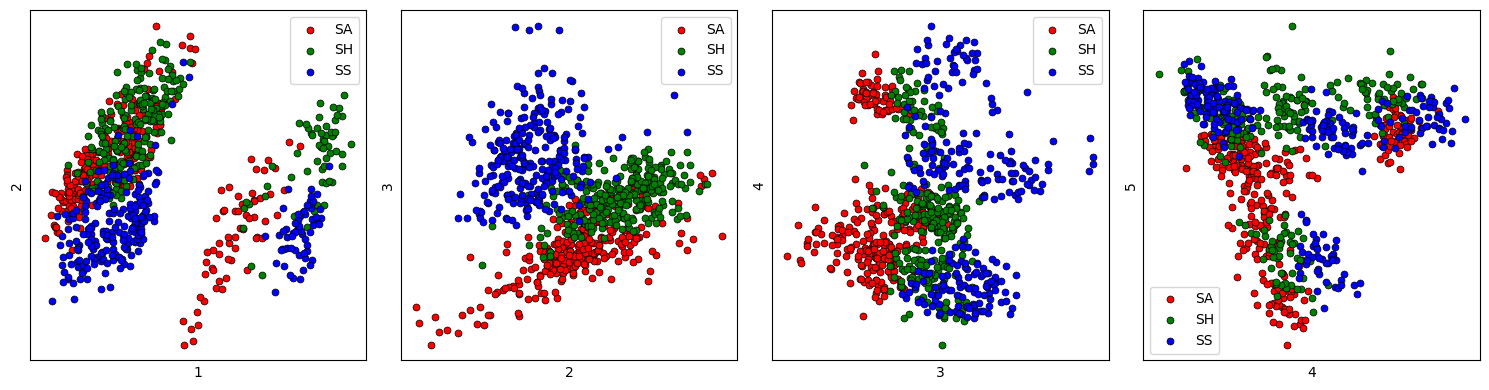

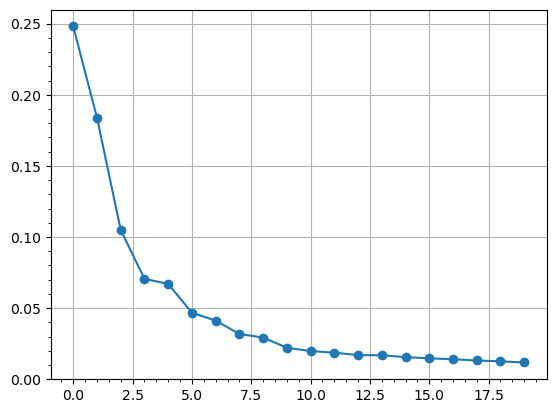

In [26]:
Ys_SA = tuple(dd2.spectra[key].y for key in dd2.keys() if "_SA_" in key)
Ys_SS = tuple(dd2.spectra[key].y for key in dd2.keys() if "_SS_" in key)
Ys_SH = tuple(dd2.spectra[key].y for key in dd2.keys() if "_SH_" in key)
Ys = tuple(dd2.spectra[key].y for key in dd2.keys())
Ys = np.concatenate(Ys, axis=0)
Ys_SA = np.concatenate(Ys_SA, axis=0)
Ys_SH = np.concatenate(Ys_SH, axis=0)
Ys_SS = np.concatenate(Ys_SS, axis=0)
Ns = tuple(len(y) for y in Ys)
# for yy in Ys_SA:
#     yy[:] = 1000*yy / yy.sum()
# for yy in Ys_SS:
#     yy[:] = 1000*yy / yy.sum()
# for yy in Ys_SH:
#     yy[:] = 1000*yy / yy.sum()
c, As, Ls = pca.find_loc_and_pc(Ys, 20)
# c_SA, As_SA, Ls_SA = pca.find_loc_and_pc(Ys_SA, 2)
# c_SS, As_SS, Ls_SS = pca.find_loc_and_pc(Ys_SS, 2)
# c_SH, As_SH, Ls_SH = pca.find_loc_and_pc(Ys_SH, 2)
U = (Ys - c) @ As.T
U_SA = (Ys_SA - c) @ As.T
U_SS = (Ys_SS - c) @ As.T
U_SH = (Ys_SH - c) @ As.T
plt.figure(figsize=(15,4))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.scatter(U_SA[:,i], U_SA[:,i+1], s=25, c='r', edgecolors='k', linewidth=0.5, label="SA")
    plt.scatter(U_SH[:,i], U_SH[:,i+1], s=25, c='g', edgecolors='k', linewidth=0.5, label="SH")
    plt.scatter(U_SS[:,i], U_SS[:,i+1], s=25, c='b', edgecolors='k', linewidth=0.5, label="SS")
    plt.xlabel(str(i+1))
    plt.ylabel(str(i+2))
    plt.xticks([])
    plt.yticks([])
    plt.legend()
plt.tight_layout()
plt.legend()

# Cs = sum((n*[c] for n,c in zip(Ns,["r","g","b"])), start=[])
plt.show()
plt.plot(Ls/Ls.sum(), marker='o')
plt.grid()
plt.minorticks_on()
plt.show()

In [ ]:
dd3.scale_by_mean()

In [36]:
dd3.save("/home/intellimath/work/spectra/13", "rm_bl")

In [2]:
d2 = spectra.SpectraCollection()
d2.load("/home/intellimath/work/spectra/13", "rm_bl")
dd2 = d2

In [3]:
dd2.drop_zeros_spectrum()
dd2.drop_notfinite()

In [ ]:
# d2.select_for_exclusion()

In [ ]:
d2.plot_spectra()

In [ ]:
d2.select_baselines(tau2=1.0e5, tau2_smooth=0.0, func=funcs.Expit(-100.0), func2_e=inventory.relative_abs_max)
# d2.select_baselines(tau2=1.0e4, tau2_smooth=10.0, func=funcs.Step(0.001), func2_e=inventory.relative_abs_max)

In [ ]:
# d2.replace_spectra_with_corrected()

In [ ]:
d2.save("/home/intellimath/work/spectra/12", "rm_bl")

In [ ]:
d2 = spectra.SpectraCollection()
d2.load("/home/intellimath/work/spectra/12", "rm_bl")

In [ ]:
d2_1 = d2.union_by_attr_value("номер_подложки", "1")
d2_1.key = "подложка_1"
d2_2 = d2.union_by_attr_value("номер_подложки", "2")
d2_2.key = "подложка_2"
d2_3 = d2.union_by_attr_value("номер_подложки", "3")
d2_3.key = "подложка_3"

dd2 = spectra.SpectraCollection()
dd2[d2_1.key] = d2_1
dd2[d2_2.key] = d2_2
dd2[d2_3.key] = d2_3

In [ ]:
# d2_1.plot_pca_spectra_2d(kind="AM", alpha=0.9, newfig=True, autoshow=False)
# d2_2.plot_pca_spectra_2d(kind="AM", alpha=0.9, newfig=False, autoshow=False)
# d2_3.plot_pca_spectra_2d(kind="AM", alpha=0.9, newfig=False, autoshow=True)

In [ ]:
dd2.plot_spectra()

In [ ]:
dd2.plot_pca_spectra()

In [ ]:
dd2.plot_pca_eigenvals(10)

In [ ]:
d2.plot_spectra_smoothed(tau2=10)

In [41]:
import mlgrad.models as models
import mlgrad.funcs as funcs
import mlgrad.funcs2 as funcs2
import mlgrad.loss as loss

import mlgrad.regr as regr
import mlgrad.af as af

Zs_SS = np.ones(Ys_SS.shape[0])
Zs_SH = np.ones(Ys_SH.shape[0])
Zs_SA = np.ones(Ys_SA.shape[0])

ys = np.concatenate((Ys_SS, Ys_SH, Ys_SA), axis=0)
zs = np.concatenate((Zs_SS, 2*Zs_SH, 3*Zs_SA), axis=0)

ys1 = np.concatenate((Ys_SS,Ys_SH), axis=0)
zs1 = np.concatenate((Zs_SS,-Zs_SH), axis=0)
ys1 = np.ascontiguousarray(ys1)
zs1 = np.ascontiguousarray(zs1)

ys2 = np.concatenate((Ys_SH,Ys_SA), axis=0)
zs2 = np.concatenate((Zs_SH,-Zs_SA), axis=0)
ys2 = np.ascontiguousarray(ys2)
zs2 = np.ascontiguousarray(zs2)

ys3 = np.concatenate((Ys_SA,Ys_SS), axis=0)
zs3 = np.concatenate((Zs_SA,-Zs_SS), axis=0)
ys3 = np.ascontiguousarray(ys3)
zs3 = np.ascontiguousarray(zs3)

In [56]:
## # print(ys.shape, zs.shape)

# body = models.FFNetworkModel()
# body.add(models.LinearLayer(ys.shape[1], 100))
# body.add(models.ScaleLayer(funcs.Logistic(1.0), 100))
# head = models.LinearModel(100)
# nnmod = models.FFNetworkFuncModel(head, body)
# nnmod.allocate()
# nnmod.init_param()

mod1 = models.SigmaNeuronModel(funcs.Sigmoidal(7.0), ys.shape[1])
mod1.allocate()
mod1.init_param()

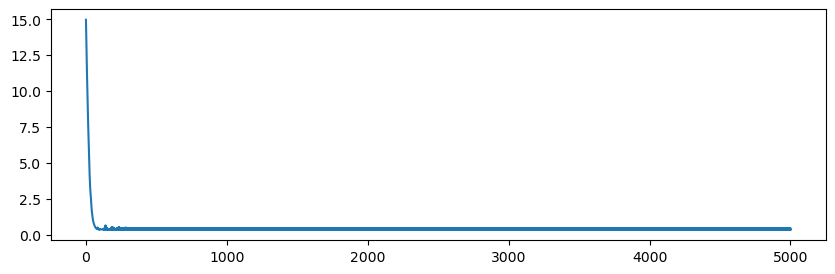

0.8121546961325967


In [58]:
alg1 = regr.regression(ys1, zs1, mod1, regnorm=funcs2.AbsoluteNorm(),
                                 normalizer=gd.Masked(mod1.n_param, 1.0e-5), 
                                 h=0.001, tau=0.7, n_iter=5000)

plt.figure(figsize=(10,3))
plt.plot(alg1.lvals)
plt.show()

from sklearn.metrics import accuracy_score
print(accuracy_score(zs1, np.sign(mod1.evaluate(ys1))))

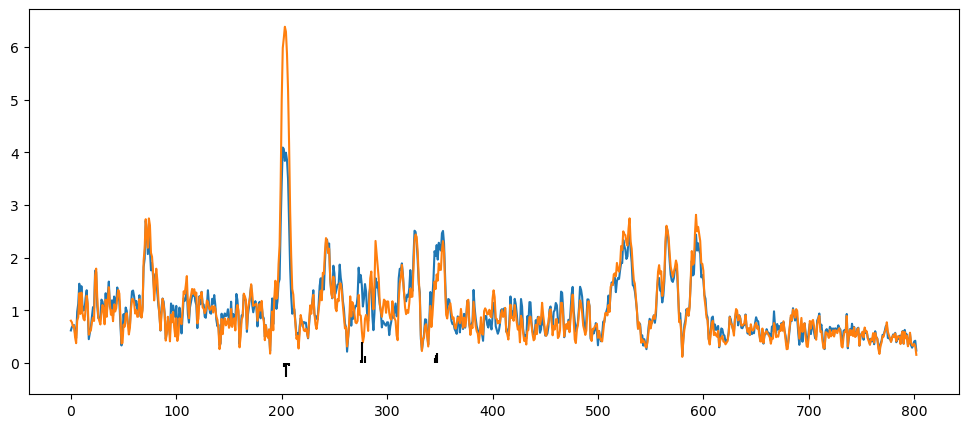

In [59]:
param1 = np.asarray(mod1.param[1:])
# print(param1[0])
param_p = param1.copy()
param_m = param1.copy()
param_p[param1 < 0] = 0
param_m[param1 > 0] = 0
plt.figure(figsize=(12,5))
plt.plot(Ys_SS.mean(axis=0), label="SS")
plt.plot(Ys_SH.mean(axis=0), label="SH")
plt.vlines(range(ys.shape[1]), 10*param_m, 10*param_p, color='k')
plt.show()

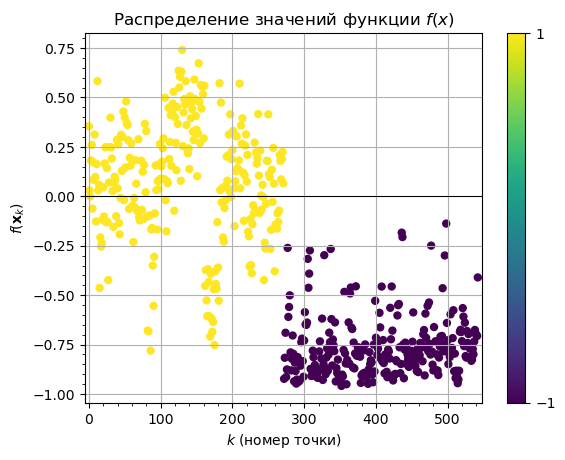

In [60]:
plots.plot_cls_function(mod1, ys1, zs1)

In [67]:
mod2 = models.SigmaNeuronModel(funcs.Sigmoidal(7.0), ys2.shape[1])
mod2.allocate()
mod2.init_param()

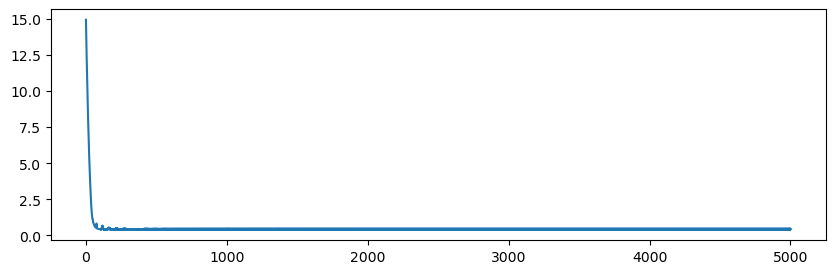

0.9365942028985508


In [68]:
alg2 = regr.regression(ys2, zs2, mod2, regnorm=funcs2.AbsoluteNorm(),
                                 normalizer=gd.Masked(mod2.n_param, 1.0e-5), 
                                 h=0.001, tau=0.7, n_iter=5000)

plt.figure(figsize=(10,3))
plt.plot(alg2.lvals)
plt.show()

from sklearn.metrics import accuracy_score
print(accuracy_score(zs2, np.sign(mod2.evaluate(ys2))))

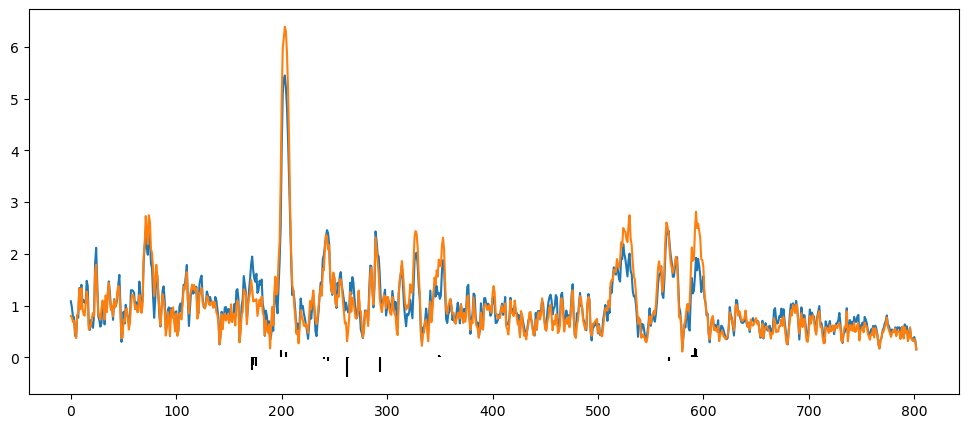

In [69]:
param2 = np.asarray(mod2.param[1:])
param2_p = param2.copy()
param2_m = param2.copy()
param2_p[param2 < 0] = 0
param2_m[param2 > 0] = 0
plt.figure(figsize=(12,5))
plt.plot(Ys_SA.mean(axis=0), label="SA")
plt.plot(Ys_SH.mean(axis=0), label="SH")
plt.vlines(range(ys2.shape[1]), 10*param2_m, 10*param2_p, color='k')
plt.show()

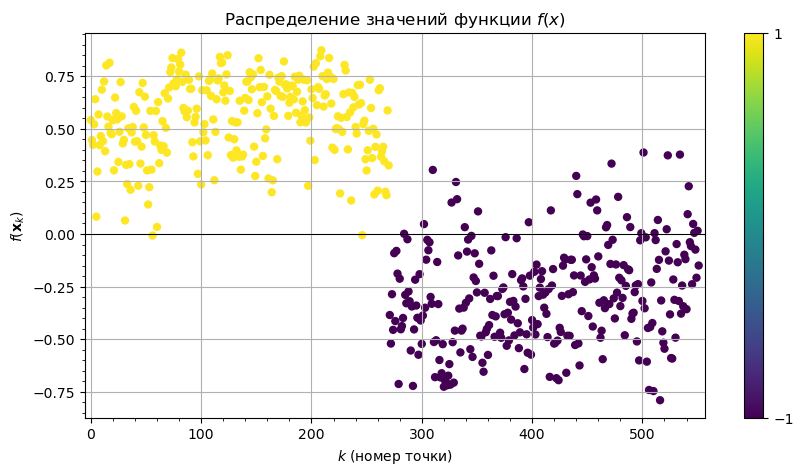

In [70]:
plt.figure(figsize=(10,5))
plots.plot_cls_function(mod2, ys2, zs2)

In [71]:
mod3 = models.SigmaNeuronModel(funcs.Sigmoidal(7.0), ys3.shape[1])
mod3.allocate()
mod3.init_param()

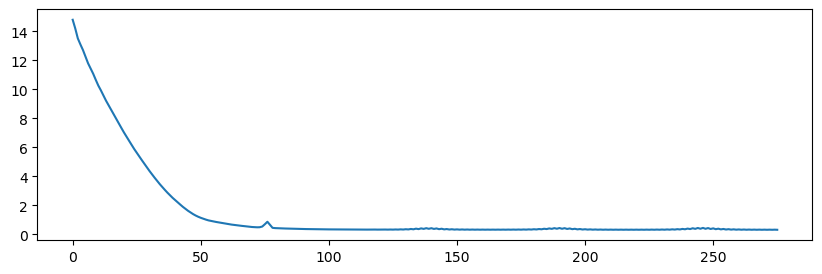

0.976491862567812


In [72]:
alg3 = regr.regression(ys3, zs3, mod3, regnorm=funcs2.AbsoluteNorm(),
                                 normalizer=gd.Masked(mod3.n_param, 1.0e-5), 
                                 h=0.001, tau=0.7, n_iter=5000)

plt.figure(figsize=(10,3))
plt.plot(alg3.lvals)
plt.show()

from sklearn.metrics import accuracy_score
print(accuracy_score(zs3, np.sign(mod3.evaluate(ys3))))

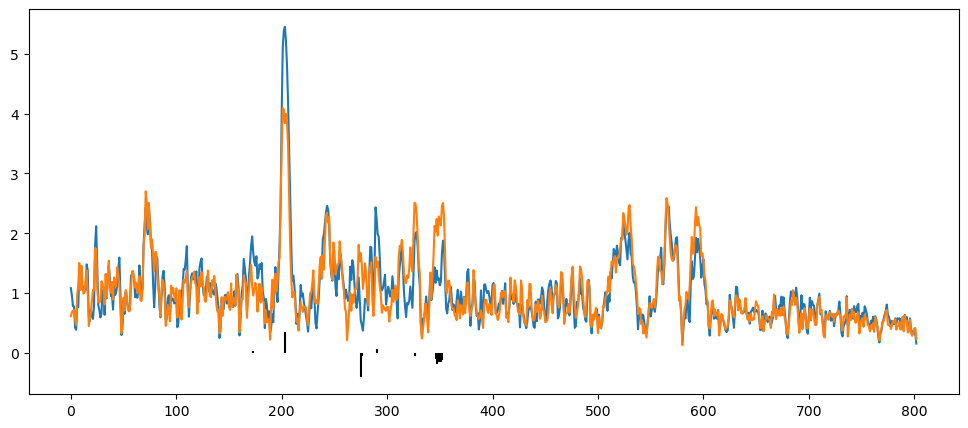

In [73]:
param3 = np.asarray(mod3.param[1:])
param3_p = param3.copy()
param3_m = param3.copy()
param3_p[param3 < 0] = 0
param3_m[param3 > 0] = 0
plt.figure(figsize=(12,5))
plt.plot(Ys_SA.mean(axis=0), label="SA")
plt.plot(Ys_SS.mean(axis=0), label="SS")
plt.vlines(range(ys3.shape[1]), 10*param3_m, 10*param3_p, color='k')
plt.show()

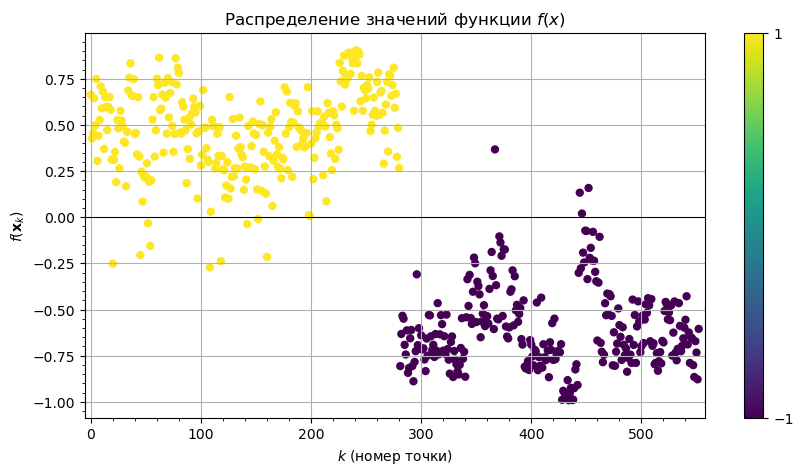

In [74]:
plt.figure(figsize=(10,5))
plots.plot_cls_function(mod3, ys3, zs3)

824
173
402
288


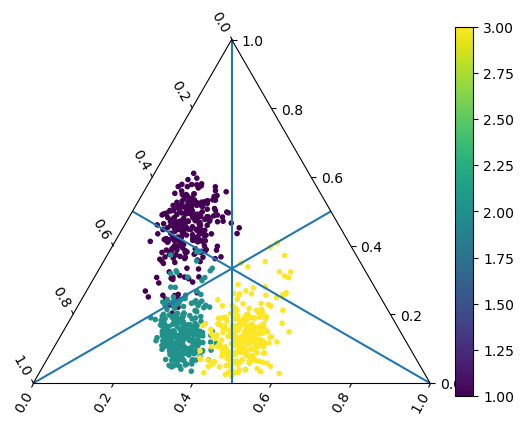

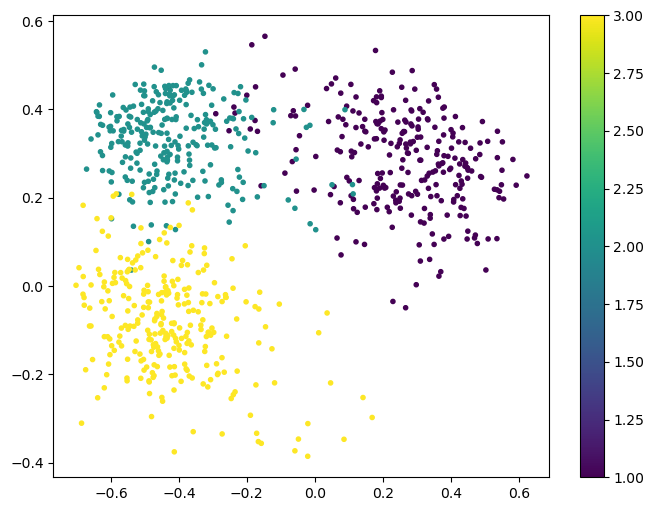

In [79]:
import mpltern
print(len(ys))

ax = plt.subplot(projection="ternary")
Z1 = mod1.evaluate(ys)
Z2 = mod2.evaluate(ys)
Z3 = mod3.evaluate(ys)
Y1 = (1 + (Z1 - Z3) / 2) / 2
Y2 = (1 + (Z2 - Z1) / 2) / 2
Y3 = (1 + (Z3 - Z2) / 2) / 2
Y1[Y1<0] = 0
Y2[Y2<0] = 0
Y3[Y3<0] = 0
print(((Z1>0) & (Z3<0)).sum())
print(((Z2>0) & (Z1<0)).sum())
print(((Z2>0) & (Z3<0)).sum())
# print(Y1)
# print(Y2)
# print(Y3)
C = [(y1,y2,y3) for y1,y2,y3 in zip(Y1,Y2,Y3)]
# cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
cs = ax.scatter(Y1, Y2, Y3, c=zs, s=9)
plt.colorbar(cs)
ax.axline(
    [0.5, 0.0, 0.0],
    [0.5, 0.5, 0.5])
ax.axline(
    [0.0, 0.5, 0.0],
    [0.5, 0.5, 0.5])
ax.axline(
    [0.0, 0.0, 0.5],
    [0.5, 0.5, 0.5])
plt.show()

zz1 = Y1
zz2 = Y2 * np.exp(2j/3 * np.pi)
zz3 = Y3 * np.exp(-2j/3 * np.pi)
C = np.concatenate((Zs_SS, 2*Zs_SH, 3*Zs_SA))
plt.figure(figsize=(8,6))
cs = plt.scatter(np.real(zz1+zz2+zz3), np.imag(zz1+zz2+zz3), s=9, c=C)
plt.colorbar(cs)
plt.show()


## 

# *************************************************************

In [ ]:
import sympy
from sympy import MatrixSymbol, Identity, latex

In [ ]:
from IPython.display import display, Latex

In [ ]:
def latex_matrix(DD):
    n = DD.shape[0]
    s = r"$$\left(\begin{array}{" + n*"l" + "}"
    for i in range(10):
        for j in range(10):
            s += latex(DD[i,j])
            if j < n-1:
                s += r"&"
            else:
                s += r"\\"
    s += r"\end{array}\right)$$"
    # print(s)
    return s

In [ ]:
E = np.eye(10, dtype="i")
D2 = np.diff(E, 2, axis=0)
print(D2)
print(D2.T @ D2)

In [ ]:
w2 = sympy.symarray("w", (10,), )
W2 = np.diag(w2[0:-2])

In [ ]:
DD2 = np.dot(np.dot(D2.T, W2), D2)

In [ ]:
display(Latex(latex_matrix(DD2)))

In [ ]:
D1 = np.diff(np.eye(10, dtype="i"), 1, axis=0, )
print(D1)
print(D1.T @ D1)

In [ ]:
w = sympy.symarray("w", (10,))
W = np.diag(w[:-1])
DD1 = np.dot(np.dot(D1.T, W), D1)

In [ ]:
display(Latex(latex_matrix(DD1)))

In [ ]:
D3 = np.diff(np.eye(10, dtype="i"), 3, axis=0, )
print(D3)
print(D3.T @ D3)

In [ ]:
w3 = sympy.symarray("w", (10,), )
W3 = np.diag(w3[0:-3])

In [ ]:
DD3 = np.dot(np.dot(D3.T, W3), D3)

In [ ]:
display(Latex(latex_matrix(DD3)))

In [ ]:
D4 = np.diff(np.eye(10, dtype="i"), 4, axis=0, )
print(D4)
print(D4.T @ D4)

In [ ]:
w4 = sympy.symarray("w", (10,), )
W4 = np.diag(w4[0:-4])

In [ ]:
DD4 = np.dot(np.dot(D4.T, W4), D4)

In [ ]:
display(Latex(latex_matrix(DD4)))

In [ ]:
import ipywidgets as widgets
import os, time

In [ ]:
buttons = []
for i in range(10):
    buttons.append(widgets.Button(description=f"  The button {i}  "))
box = ipywidgets.Box(buttons)
box.layout = widgets.Layout(flex_flow="row wrap")
box

In [ ]:
fp = widgets.FloatProgress(min=0, max=10, value=0, bar_style="success", description="abcdefghijklmnopqrstuv")
fp.style.width=32
display(fp)
for i in range(11):
    time.sleep(1)
    fp.value=i